Plots notebook

In [5]:
import pandas as pd
from matplotlib import pyplot as plt
import haversine as hs

In [30]:
filename = "2025-07-31_23-36-03"
input = pd.read_csv(f"data/input/1Hz/{filename}.csv")
truth = pd.read_csv(f"data/truth/1Hz/{filename}_truth.csv")
intermittent = pd.read_csv(f"data/intermittent/10s/1Hz/{filename}.csv")

In [31]:
input

,time,bearingAccuracy,speedAccuracy,verticalAccuracy,horizontalAccuracy,speed,bearing,altitude,longitude,latitude,...,gyro_y,gyro_x,mag_z,mag_y,mag_x,relativeAltitude,pressure,grav_z,grav_y,grav_x
0,2025-07-31 23:36:04+00:00,0.000000,0.03,1.0,0.510204,0.00,0.000000,54.0,-75.223677,40.040609,...,-0.000298,0.000010,-25.140749,47.510989,-89.611586,0.530968,1003.602158,-0.304350,9.801719,0.264168
1,2025-07-31 23:36:05+00:00,0.000000,0.03,1.0,0.510204,0.00,0.000000,54.0,-75.223677,40.040609,...,-0.000257,-0.000006,-25.966724,47.677111,-91.994342,0.706101,1003.581310,-0.302176,9.802042,0.254509
2,2025-07-31 23:36:06+00:00,0.000000,0.02,1.0,0.510204,0.00,0.000000,54.0,-75.223677,40.040609,...,-0.000163,0.000291,-26.032115,47.694435,-91.975310,0.751400,1003.575897,-0.302514,9.802259,0.245606
3,2025-07-31 23:36:07+00:00,0.000000,0.01,1.0,0.510204,0.00,0.000000,54.0,-75.223677,40.040609,...,0.000120,0.001316,-26.199245,47.734151,-91.920644,0.777691,1003.572754,-0.300309,9.802489,0.239049
4,2025-07-31 23:36:08+00:00,0.000000,0.02,1.0,0.510204,0.00,0.000000,54.0,-75.223677,40.040609,...,-0.001146,-0.001619,-25.089238,47.711365,-90.786237,0.663346,1003.586380,-0.300937,9.802569,0.234912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13445,2025-08-01 03:20:09+00:00,66.500000,0.19,2.0,7.653061,0.01,165.500000,-19.0,-72.553092,40.995496,...,-0.000518,0.000397,4.531129,50.064240,-73.462237,-100.225145,1015.669293,-0.146170,9.798213,-0.457957
13446,2025-08-01 03:20:10+00:00,66.500000,0.19,2.0,7.142857,0.02,165.500000,-19.0,-72.553093,40.995496,...,0.000995,-0.000563,5.068734,50.039519,-72.984303,-99.741477,1015.611130,-0.139475,9.798287,-0.458509
13447,2025-08-01 03:20:11+00:00,66.500000,0.20,2.0,7.653061,0.02,165.399994,-19.0,-72.553093,40.995496,...,-0.000626,0.000701,4.205828,50.210319,-74.939840,-99.980734,1015.639847,-0.140121,9.798371,-0.456500
13448,2025-08-01 03:20:12+00:00,66.500000,0.22,2.0,8.163265,0.02,165.399994,-19.0,-72.553093,40.995496,...,-0.000430,-0.000001,3.798958,50.150295,-74.888967,-100.285124,1015.676498,-0.152434,9.797998,-0.460560


In [32]:
gps = input[["latitude", "longitude"]].to_numpy()
est = truth[["latitude", "longitude"]].to_numpy()
inter = intermittent[["latitude", "longitude"]].to_numpy()
gps_alt = input[["altitude"]].to_numpy()
est_alt = truth[["altitude"]].to_numpy()
inter_alt = intermittent[["altitude"]].to_numpy()

In [37]:
truth_planar_error = hs.haversine_vector(gps, est, hs.Unit.METERS)
truth_vertical_error = gps_alt - est_alt
inter_planar_error = hs.haversine_vector(est, inter, hs.Unit.METERS)
inter_vertical_error = est_alt - inter_alt

In [38]:
time = pd.to_datetime(input["time"])
time = time - time[0]

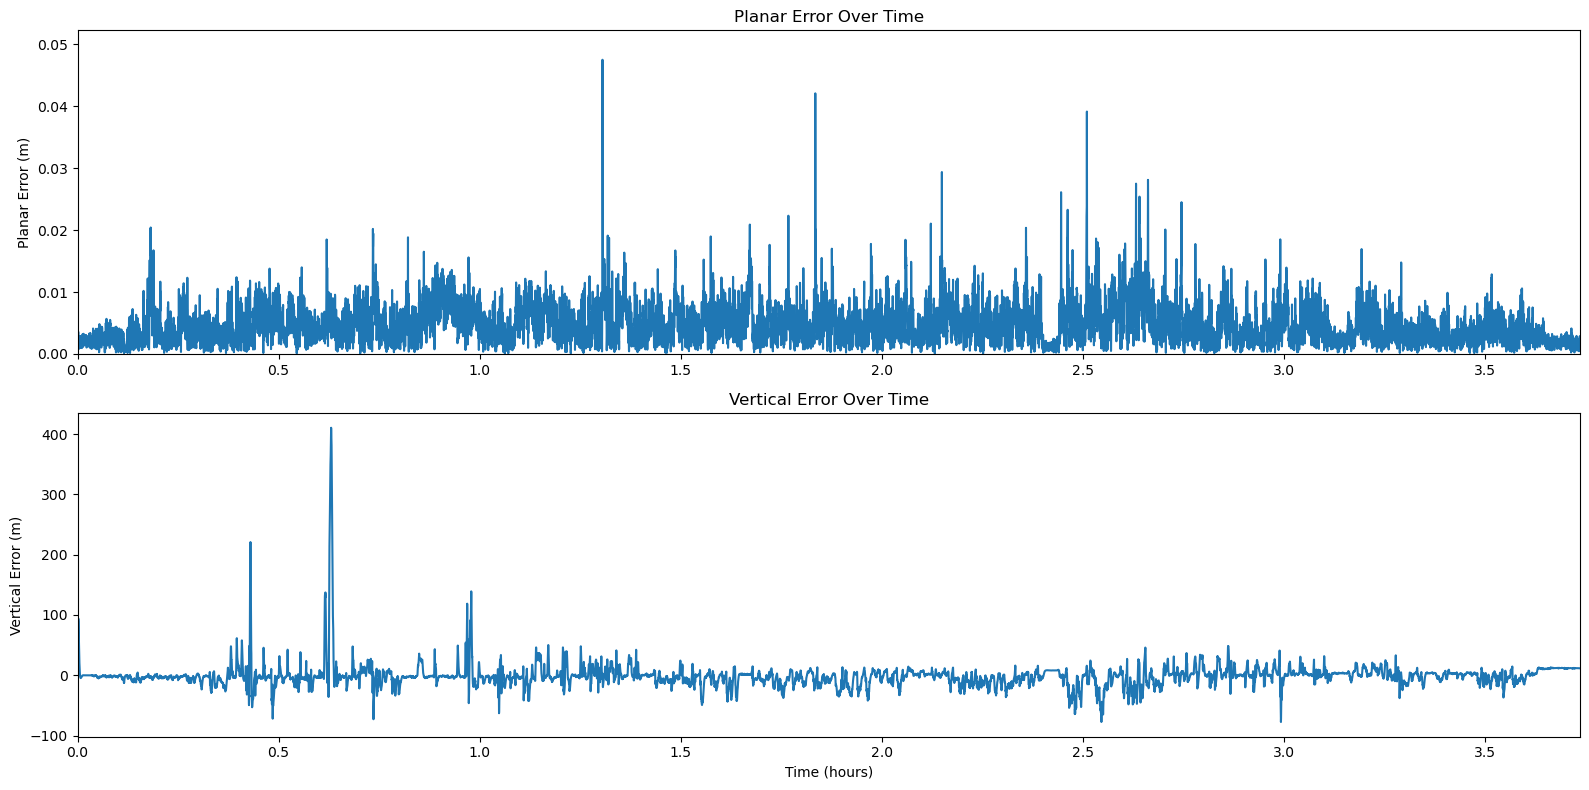

In [61]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8))
ax[0].plot(time.dt.total_seconds() / 3600, truth_planar_error, label="Truth")
#ax[0].plot(time.dt.total_seconds() / 3600, inter_planar_error, label="Intermittent")
#ax[0].set_xlabel("Time (hours)")
ax[0].set_ylabel("Planar Error (m)")
ax[0].set_title("Planar Error Over Time")
ax[0].set_xlim([0, time.dt.total_seconds().max() / 3600])
ax[0].set_ylim([0, truth_planar_error.max() * 1.1])

ax[1].plot(time.dt.total_seconds() / 3600, truth_vertical_error, label="Truth")
ax[1].set_xlabel("Time (hours)")
ax[1].set_ylabel("Vertical Error (m)")
ax[1].set_title("Vertical Error Over Time")
ax[1].set_xlim([0, time.dt.total_seconds().max() / 3600])

fig.tight_layout()
plt.savefig("paper/images/example_truth_error.png", dpi=300)

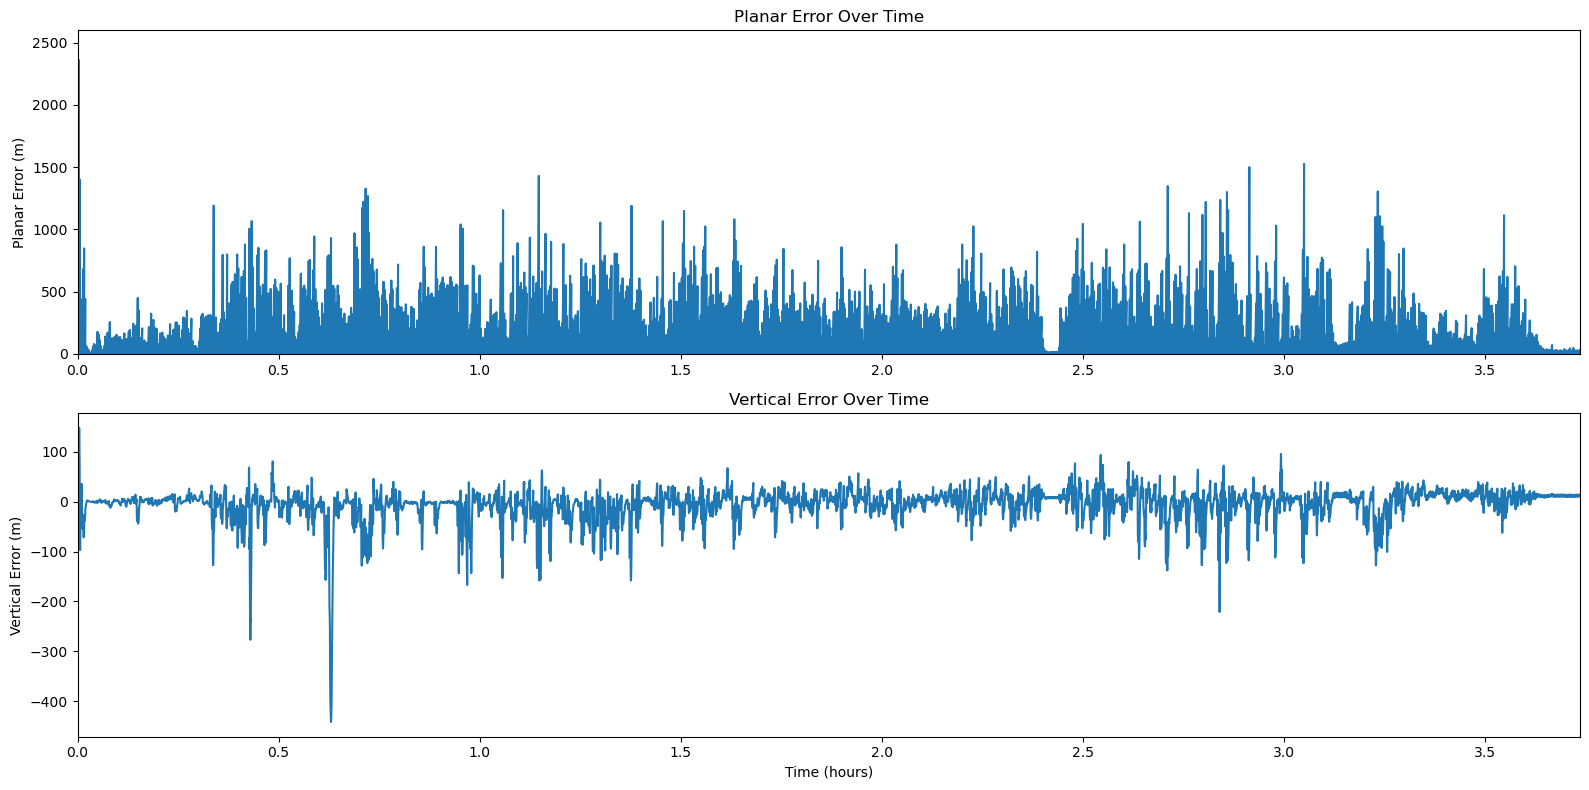

In [60]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8))
ax[0].plot(time.dt.total_seconds() / 3600, inter_planar_error, label="Intermittent")
ax[0].set_ylabel("Planar Error (m)")
ax[0].set_title("Planar Error Over Time")
ax[0].set_xlim([0, time.dt.total_seconds().max() / 3600])
ax[0].set_ylim([0, inter_planar_error.max() * 1.1])

ax[1].plot(time.dt.total_seconds() / 3600, inter_vertical_error, label="Intermittent")
ax[1].set_xlabel("Time (hours)")
ax[1].set_ylabel("Vertical Error (m)")
ax[1].set_title("Vertical Error Over Time")
ax[1].set_xlim([0, time.dt.total_seconds().max() / 3600])

fig.tight_layout()
plt.savefig("paper/images/example_inter_error.png", dpi=300)

In [16]:
import numpy as np
from scipy.linalg import sqrtm, eig

In [30]:
n = 2 * 15 + 1
z = np.array([[2]])
z_hat = np.random.multivariate_normal(mean=(np.zeros((n, 1))+z).squeeze(), cov=np.diag(np.ones(n))*0.01)

In [31]:
(z - z_hat) @ (z - z_hat).T

array([[0.32736455]])

In [32]:
(z - z_hat).shape

(1, 31)

In [48]:
wc = np.ones((n,)) * 0.01

In [49]:
wc * np.random.rand(15, n) @ (z - z_hat).T

array([[-0.00126628],
       [-0.00322521],
       [-0.00086502],
       [-0.00182004],
       [-0.00315206],
       [-0.00153929],
       [-0.00589282],
       [-0.00249964],
       [-0.00129145],
       [-0.00348286],
       [-0.00159955],
       [-0.0041844 ],
       [-0.00286226],
       [-0.00388591],
       [-0.00144212]])

In [46]:
wc.shape

(31, 1)